На семинаре разберём несколько известных датасетов для рекомендательных систем. Для каждого датасета посмотрим, как устроены данные, посчитаем основные статистики и построим графики.


## Где искать данные

Для экспериментов с рекомендательными системами обычно нужны два типа данных:

- **взаимодействия**: просмотры, клики, покупки, оценки, добавления в корзину и т. п.;
- **метаданные объектов**: названия, описания, категории, изображения и другие признаки.

В публичных RecSys-датасетах взаимодействий много, а качественных метаданных заметно меньше. Поэтому сначала стоит определить, что именно нужно для экспериментов.

Если конкретный домен пока не важен, удобнее начать с каталогов и подборок.

| Источник | Когда полезен |
|---|---|
| [RecSysDatasets](https://github.com/RUCAIBox/RecSysDatasets) | Большой каталог RecSys-датасетов с краткими описаниями и статистиками |
| [RecZoo Datasets](https://github.com/reczoo/Datasets) | Уже приведённые к единому формату датасеты для воспроизводимых экспериментов |
| [GroupLens](https://grouplens.org/datasets/) | Для учебных экспериментов; здесь находится семейство MovieLens |
| [Datasets by J. McAuley](https://cseweb.ucsd.edu/~jmcauley/datasets.html) | Большая исследовательская коллекция: Amazon, Goodreads и другие данные |
| [Datasets by Yongfeng Zhang](https://yongfeng.me/dataset/) | Дополнительные исследовательские датасеты, преимущественно из китайских сервисов |
| [DataMaestro](https://datamaestro-text.readthedocs.io/en/latest/datasets/ir.html) | Если задача ближе к информационному поиску и работе с текстом |


Если модель должна использовать текст, изображения, категории или другие признаки объектов, например для холодного старта, выбирать датасет нужно внимательнее.

| Домен | Датасеты | Взаимодействия | Метаданные |
|---|---|---|---|
| Фильмы | [MovieLens](https://grouplens.org/datasets/movielens/), [Netflix Prize](https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data?select=README) | Оценки | В MovieLens — названия и жанры; Netflix Prize в основном полезен именно как interaction dataset |
| Книги | [Goodreads](https://cseweb.ucsd.edu/~jmcauley/datasets/goodreads.html) | Оценки, отзывы, полки | Названия, описания и другие признаки книг; тексты в основном английские |
| Товары | [Amazon Reviews 2023](https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023) | Оценки и отзывы | Названия, категории, бренды, описания, изображения |
| Поиск товаров | [Amazon ESCI](https://github.com/amazon-science/esci-data), [ESCI + Images](https://github.com/Crossing-Minds/shopping-queries-image-dataset) | Запрос → товар, оценки релевантности | Тексты товаров; существует дополнение с изображениями |
| Короткие видео | [MicroLens](https://github.com/westlake-repl/MicroLens) | Просмотры | Признаки видео |
| Новости | [MIND](https://msnews.github.io/) | Показы и клики | Заголовки, краткие тексты, категории, сущности |
| Несколько доменов | [NineRec](https://github.com/westlake-repl/NineRec), [PixelRec](https://github.com/westlake-repl/PixelRec) | Пользовательские взаимодействия | Тексты и изображения |
| Организации | [Yandex Geo Reviews](https://huggingface.co/datasets/d0rj/geo-reviews-dataset-2023) | Отзывы | Русскоязычные тексты отзывов и данные об организациях |
| Продукты | [Instacart](https://www.kaggle.com/c/instacart-market-basket-analysis/data), [Amazon Grocery](https://huggingface.co/datasets/recmeapp/Amazon-grocery) | Корзины и повторные покупки / рекомендательные диалоги | Зависит от конкретного набора |
| Интернет-магазин | [E-commerce Behavior Data](https://huggingface.co/datasets/kevykibbz/ecommerce-behavior-data-from-multi-category-store_oct-nov_2019) | Просмотры, корзина, покупки | Метаданные ограничены, полноценных текстовых описаний почти нет |

Иногда пользовательские взаимодействия вообще не нужны. Например, если задача — построить поиск похожих объектов.

Для таких экспериментов можно использовать:

- [KazanExpress Products](https://huggingface.co/datasets/nyuuzyou/ke-products) — каталог товаров;
- [Open Food Facts](https://huggingface.co/datasets/openfoodfacts/product-database) — большая база продуктов питания;
- [Shopify Product Catalogue](https://huggingface.co/datasets/Shopify/product-catalogue) — каталог товаров Shopify.

Важно: такие наборы сами по себе не позволяют обучить классическую рекомендательную, поскольку в них нет истории взаимодействий пользователей.


Если задача не требует обучения представлений объектов или пользователей с нуля, можно посмотреть [VK-LSVD](https://huggingface.co/datasets/deepvk/VK-LSVD), [Yambda](https://huggingface.co/datasets/yandex/yambda) и [T-ECD](https://huggingface.co/datasets/t-tech/T-ECD). Эти датасеты хороши в том числе тем, что они являются индустриальными и отражают сложность устройства реальных данных.

## Датасеты семинара

| Датасет | Что рекомендуем | Взаимодействие | Информация об объектах |
|---|---|---|---|
| [MovieLens 1M](https://grouplens.org/datasets/movielens/1m/) | фильмы | оценка от 1 до 5 | английское название и жанры |
| [Amazon Reviews 2014](https://cseweb.ucsd.edu/~jmcauley/datasets/amazon/links.html) | товары | оценка и отзыв | название, категория, бренд, описание |
| [Criteo Click Logs](https://ailab.criteo.com/download-criteo-1tb-click-logs-dataset/) | рекламные объявления | показ и клик | обезличенные числовые и категориальные признаки |
| [Last.fm 2K](https://grouplens.org/datasets/hetrec-2011/) | исполнители | число прослушиваний | имя исполнителя и пользовательские теги |
| [Book-Crossing](http://www2.informatik.uni-freiburg.de/~cziegler/BX/) | книги | оценка или неявное взаимодействие | название, автор, издатель и год издания |
| [MIND](https://msnews.github.io/) | новости | показ и клик | английский заголовок, краткий текст, категория и сущности |

Эти датасеты описывают разные виды поведения. Оценка фильма, прослушивание песни и клик по рекламе — не одно и то же. Поэтому одинаковые статистики и метрики в разных задачах могут иметь разный смысл.

Еще важно: отсутствие оценки не означает, что айтем не понравился пользователю: вероятно, пользователь его просто не видел!


При первом запуске данные скачиваются в каталог `data/11_seminar`. Повторно уже загруженные файлы не скачиваются.

In [ ]:
from pathlib import Path
from collections import Counter
import ast
import gzip
import json
import re
import shutil
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

DATA_DIR = Path("data/11_seminar")
DOWNLOAD_DATA = True

In [7]:
URLS = {
    "amazon_reviews": "https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Digital_Music_5.json.gz",
    "amazon_meta": "https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/meta_Digital_Music.json.gz",
    "movielens": "https://files.grouplens.org/datasets/movielens/ml-1m.zip",
    "lastfm": "https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip",
}


def download(url, path):
    path = Path(path)
    if path.exists():
        return path
    path.parent.mkdir(parents=True, exist_ok=True)
    print("Скачиваем", path.name)
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(request) as response, open(path, "wb") as output:
        shutil.copyfileobj(response, output)
    return path


def download_zip(url, directory):
    directory = Path(directory)
    marker = directory / ".ready"
    if marker.exists():
        return
    archive = download(url, directory / "data.zip")
    with zipfile.ZipFile(archive) as file:
        file.extractall(directory)
    marker.touch()


def download_book_crossing():
    directory = DATA_DIR / "book_crossing"
    base = "https://raw.githubusercontent.com/rochitasundar/Collaborative-Filtering-Book-Recommendation-System/master"
    for name in ["BX-Book-Ratings.csv", "BX-Books.csv", "BX-Users.csv"]:
        download(f"{base}/{name}", directory / name)


if DOWNLOAD_DATA:
    download(URLS["amazon_reviews"], DATA_DIR / "amazon/reviews_Digital_Music_5.json.gz")
    download(URLS["amazon_meta"], DATA_DIR / "amazon/meta_Digital_Music.json.gz")
    download_zip(URLS["movielens"], DATA_DIR / "movielens")
    download_zip(URLS["lastfm"], DATA_DIR / "lastfm")
    download_book_crossing()

MIND придется руками скачать [отсюда](https://www.kaggle.com/datasets/arashnic/mind-news-dataset?select=MINDsmall_train$0).

Для всех датасетов посчитаем:

- число пользователей;
- число объектов;
- число взаимодействий;
- долю незаполненных ячеек в матрице «пользователь — объект» (sparsity).

Если одна и та же пара встречается несколько раз, при расчёте разреженности учитываем её один раз.

In [17]:
summary = []


def add_stats(name, data, user_col="user_id", item_col="item_id"):
    users = data[user_col].nunique()
    items = data[item_col].nunique()
    interactions = len(data)
    pairs = data[[user_col, item_col]].drop_duplicates().shape[0]
    sparsity = 1 - pairs / (users * items)

    row = {
        "Датасет": name,
        "Пользователи": users,
        "Объекты": items,
        "Взаимодействия": interactions,
        "Разреженность": sparsity,
    }
    summary.append(row)
    display(pd.DataFrame([row]).style.format({"Разреженность": "{:.3%}"}))


def plot_popularity(data, item_col="item_id", title="Популярность объектов"):
    popularity = data[item_col].value_counts()
    plt.plot(np.arange(1, len(popularity) + 1), popularity.values)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Место объекта по популярности")
    plt.ylabel("Число взаимодействий")
    plt.title(title)
    plt.show()


STOPWORDS = {"amp", "the", "and", "for", "with", "from", "this", "that", "vol"}


def plot_words(texts, title, n=15):
    words = Counter(
        word
        for text in texts.dropna().astype(str).str.lower()
        for word in re.findall(r"[a-z]{3,}", text)
        if word not in STOPWORDS
    )
    top = pd.DataFrame(words.most_common(n), columns=["Слово", "Частота"])
    sns.barplot(data=top, x="Частота", y="Слово", color="#4c78a8")
    plt.title(title)
    plt.show()


def find_file(directory, name):
    files = list(Path(directory).rglob(name))
    if not files:
        raise FileNotFoundError(f"Не найден файл {name} в каталоге {directory}")
    return files[0]


### MovieLens 1M

MovieLens 1M содержит около миллиона оценок фильмов от примерно шести тысяч пользователей. В датасете есть английские названия фильмов и список жанров. Каждый пользователь поставил не менее 20 оценок, поэтому данные почти не отражают ситуацию с новыми пользователями.


,Датасет,Пользователи,Объекты,Взаимодействия,Разреженность
0,MovieLens 1M,6040,3706,1000209,95.532%


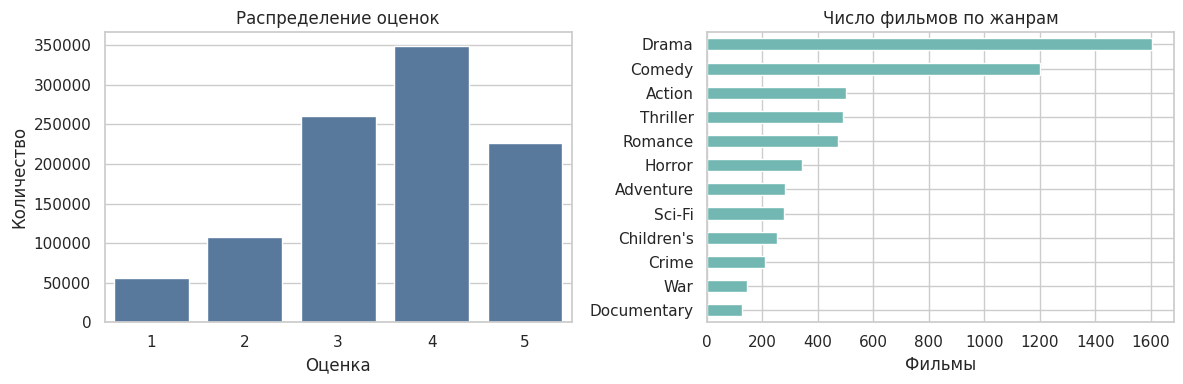

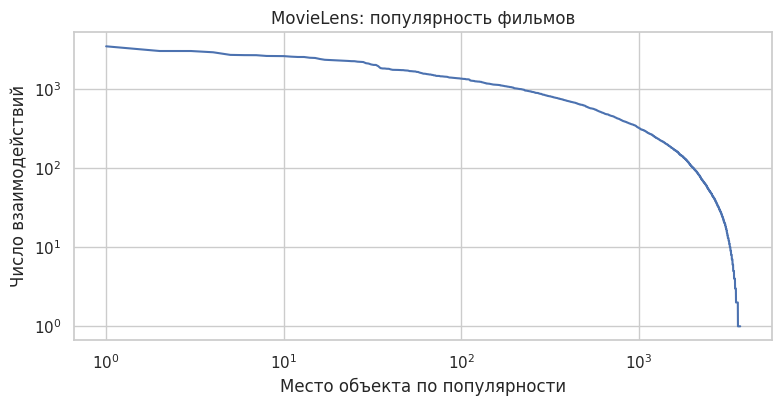

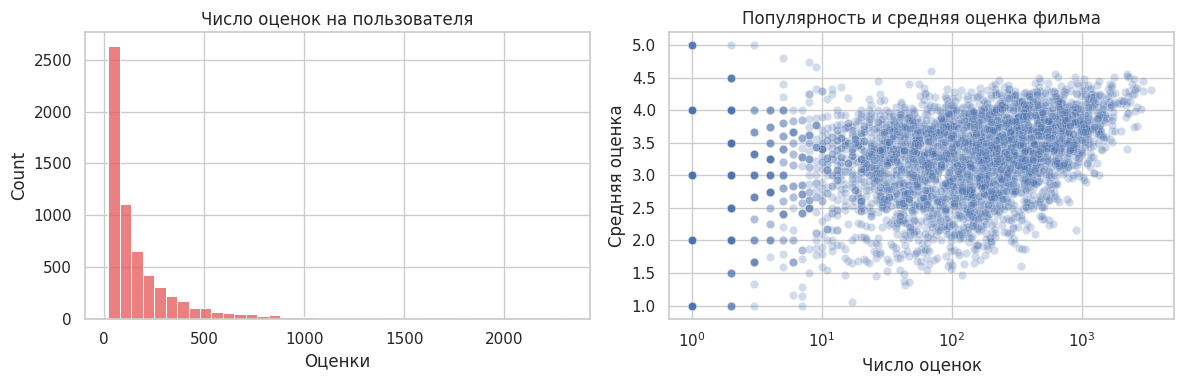

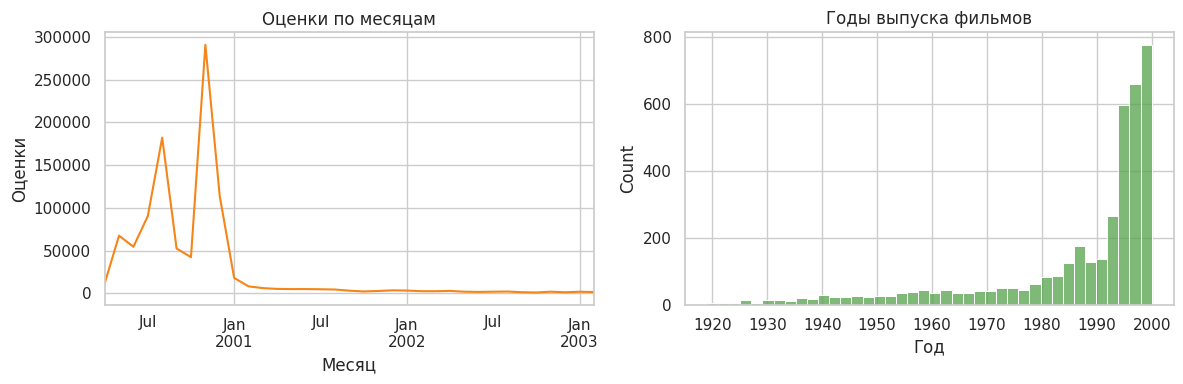

Средняя оценка: 3.58
Медианное число оценок пользователя: 96


In [19]:
ml_dir = find_file(DATA_DIR / "movielens", "ratings.dat").parent

ratings = pd.read_csv(
    ml_dir / "ratings.dat",
    sep="::",
    engine="python",
    names=["user_id", "item_id", "rating", "timestamp"],
)
movies = pd.read_csv(
    ml_dir / "movies.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["item_id", "title", "genres"],
)

add_stats("MovieLens 1M", ratings)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=ratings, x="rating", color="#4c78a8", ax=axes[0])
axes[0].set(title="Распределение оценок", xlabel="Оценка", ylabel="Количество")

genre_counts = movies["genres"].str.get_dummies("|").sum().sort_values().tail(12)
genre_counts.plot.barh(ax=axes[1], color="#72b7b2", title="Число фильмов по жанрам")
axes[1].set_xlabel("Фильмы")
plt.tight_layout()
plt.show()

plot_popularity(ratings, title="MovieLens: популярность фильмов")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ratings_per_user = ratings.groupby("user_id").size()
sns.histplot(ratings_per_user, bins=40, ax=axes[0], color="#e45756")
axes[0].set(title="Число оценок на пользователя", xlabel="Оценки")

movie_stats = ratings.groupby("item_id")["rating"].agg(["mean", "count"])
sns.scatterplot(data=movie_stats, x="count", y="mean", alpha=0.25, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set(title="Популярность и средняя оценка фильма", xlabel="Число оценок", ylabel="Средняя оценка")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ratings["date"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings.set_index("date").resample("ME").size().plot(ax=axes[0], color="#f58518")
axes[0].set(title="Оценки по месяцам", xlabel="Месяц", ylabel="Оценки")

release_year = pd.to_numeric(movies["title"].str.extract(r"\((\d{4})\)$")[0], errors="coerce")
sns.histplot(release_year, bins=40, ax=axes[1], color="#54a24b")
axes[1].set(title="Годы выпуска фильмов", xlabel="Год")
plt.tight_layout()
plt.show()

print(f"Средняя оценка: {ratings['rating'].mean():.2f}")
print(f"Медианное число оценок пользователя: {ratings_per_user.median():.0f}")


### Amazon Reviews 2014

Amazon Reviews 2014 содержит отзывы и сведения о товарах из 24 категорий. Полный датасет очень большой, поэтому для семинара возьмём категорию **Digital Music** после фильтрации 5-core: у каждого оставшегося пользователя и товара есть не менее пяти взаимодействий.

В отзывах есть идентификаторы пользователя и товара, оценка, текст и время. В отдельном файле хранятся названия и другие сведения о товарах. Названия и отзывы написаны на английском.


,Датасет,Пользователи,Объекты,Взаимодействия,Разреженность
0,Amazon Digital Music,5541,3568,64706,99.673%


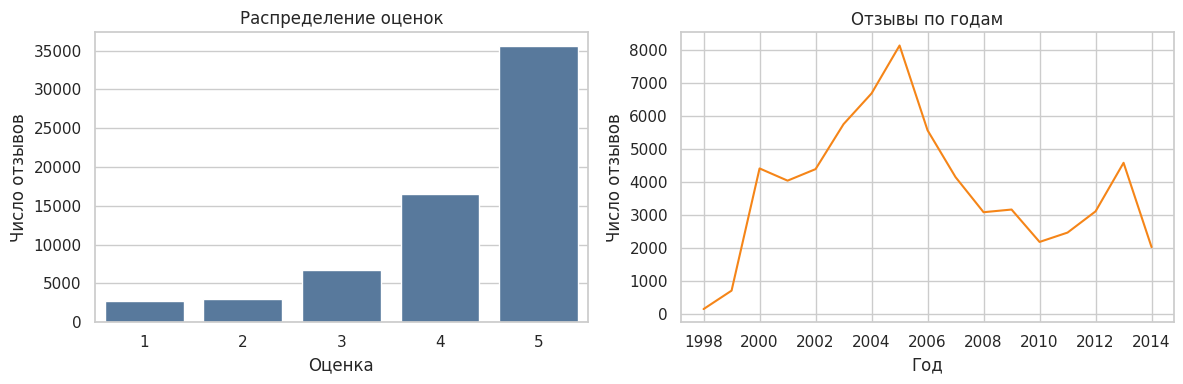

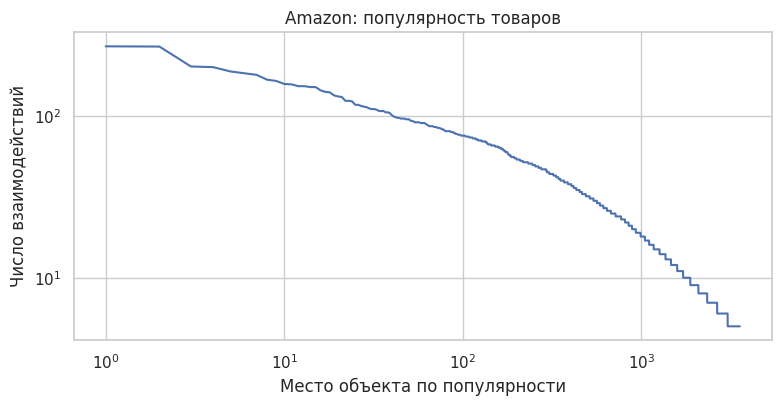

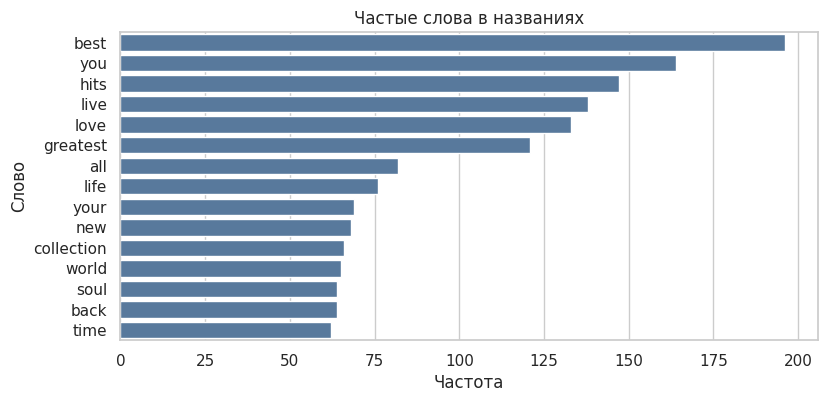

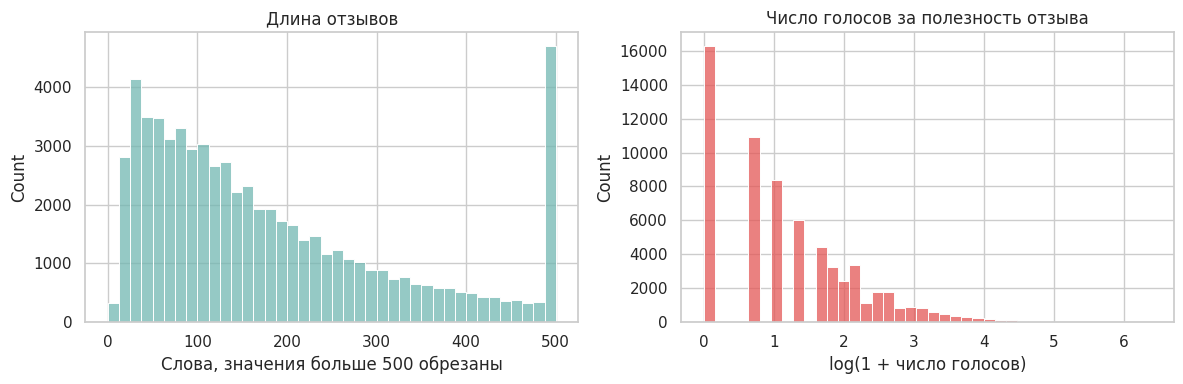

Средняя оценка: 4.22
Медианная длина отзыва: 140 слов


In [18]:
def read_amazon(path):
    try:
        return pd.read_json(path, lines=True, compression="gzip")
    except ValueError:
        rows = []
        with gzip.open(path, "rt", encoding="utf-8") as file:
            for line_number, line in enumerate(file):
                rows.append(ast.literal_eval(line))
        return pd.DataFrame(rows)


amazon_reviews = read_amazon(DATA_DIR / "amazon/reviews_Digital_Music_5.json.gz")
amazon_meta = read_amazon(DATA_DIR / "amazon/meta_Digital_Music.json.gz")

add_stats("Amazon Digital Music", amazon_reviews, "reviewerID", "asin")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=amazon_reviews, x="overall", color="#4c78a8", ax=axes[0])
axes[0].set(title="Распределение оценок", xlabel="Оценка", ylabel="Число отзывов")

reviews_by_year = pd.to_datetime(amazon_reviews["unixReviewTime"], unit="s").dt.year.value_counts().sort_index()
reviews_by_year.plot(ax=axes[1], color="#f58518", title="Отзывы по годам")
axes[1].set(xlabel="Год", ylabel="Число отзывов")
plt.tight_layout()
plt.show()

plot_popularity(amazon_reviews, "asin", "Amazon: популярность товаров")
plot_words(amazon_meta["title"], "Частые слова в названиях")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
review_length = amazon_reviews["reviewText"].fillna("").str.split().str.len()
sns.histplot(review_length.clip(upper=500), bins=40, ax=axes[0], color="#72b7b2")
axes[0].set(title="Длина отзывов", xlabel="Слова, значения больше 500 обрезаны")

helpful_votes = amazon_reviews["helpful"].apply(lambda x: x[1] if isinstance(x, list) else 0)
sns.histplot(np.log1p(helpful_votes), bins=40, ax=axes[1], color="#e45756")
axes[1].set(title="Число голосов за полезность отзыва", xlabel="log(1 + число голосов)")
plt.tight_layout()
plt.show()

print(f"Средняя оценка: {amazon_reviews['overall'].mean():.2f}")
print(f"Медианная длина отзыва: {review_length.median():.0f} слов")


### Last.fm 2K

В Last.fm одна строка содержит пользователя, исполнителя и суммарное число прослушиваний. Это уже агрегированные данные: повторных строк для каждой пары нет, но число прослушиваний может различаться на несколько порядков.


,Датасет,Пользователи,Объекты,Взаимодействия,Разреженность
0,Last.fm 2K,1892,17632,92834,99.722%


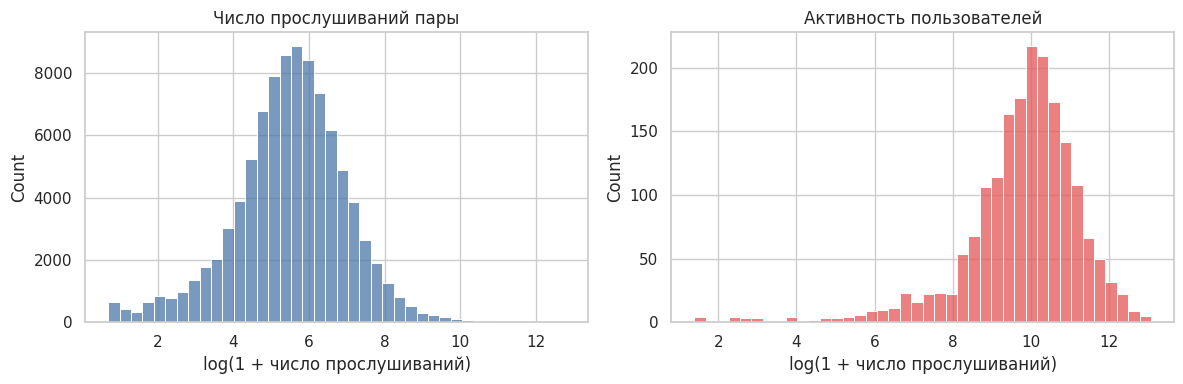

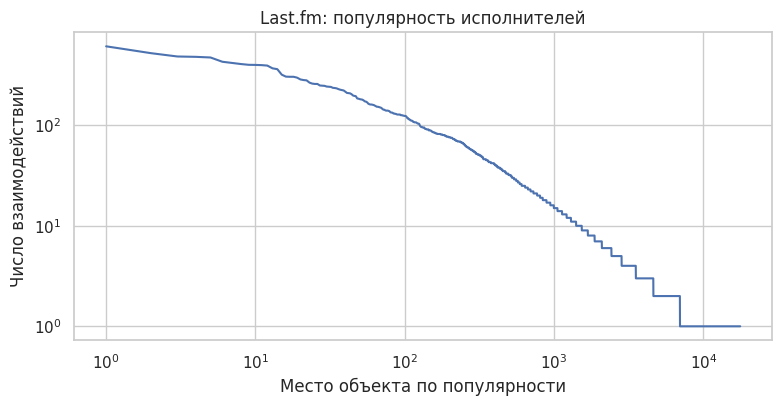

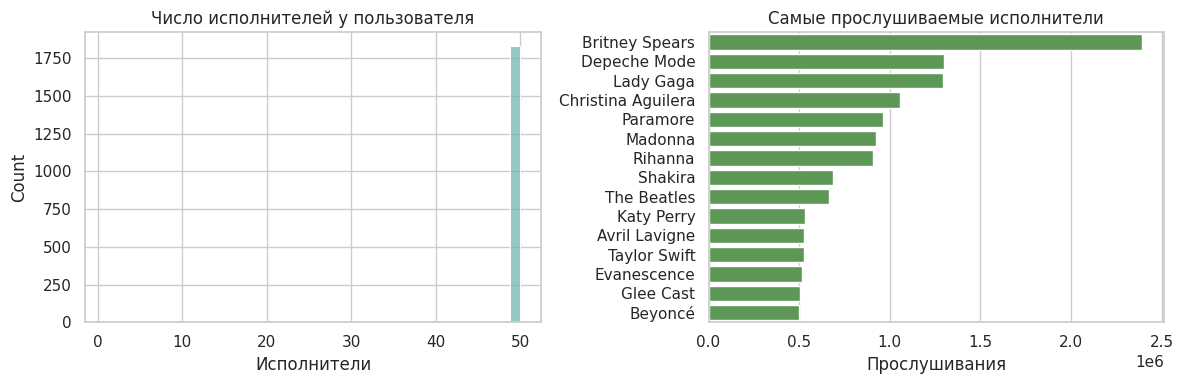

Медианное число исполнителей у пользователя: 50
На 1% исполнителей приходится 51.9% прослушиваний


In [20]:
lastfm_dir = find_file(DATA_DIR / "lastfm", "user_artists.dat").parent
listens = pd.read_csv(lastfm_dir / "user_artists.dat", sep="\t")
artists = pd.read_csv(lastfm_dir / "artists.dat", sep="\t")

add_stats("Last.fm 2K", listens, "userID", "artistID")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(np.log1p(listens["weight"]), bins=40, ax=axes[0], color="#4c78a8")
axes[0].set(title="Число прослушиваний пары", xlabel="log(1 + число прослушиваний)")

user_activity = listens.groupby("userID")["weight"].sum()
sns.histplot(np.log1p(user_activity), bins=40, ax=axes[1], color="#e45756")
axes[1].set(title="Активность пользователей", xlabel="log(1 + число прослушиваний)")
plt.tight_layout()
plt.show()

plot_popularity(listens, "artistID", "Last.fm: популярность исполнителей")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
artists_per_user = listens.groupby("userID")["artistID"].nunique()
sns.histplot(artists_per_user, bins=40, ax=axes[0], color="#72b7b2")
axes[0].set(title="Число исполнителей у пользователя", xlabel="Исполнители")

artist_plays = listens.groupby("artistID")["weight"].sum().nlargest(15)
top_artists = artists.set_index("id")["name"].reindex(artist_plays.index)
sns.barplot(x=artist_plays.values, y=top_artists.values, ax=axes[1], color="#54a24b")
axes[1].set(title="Самые прослушиваемые исполнители", xlabel="Прослушивания", ylabel="")
plt.tight_layout()
plt.show()

top_one_percent = max(1, int(listens["artistID"].nunique() * 0.01))
share = listens.groupby("artistID")["weight"].sum().nlargest(top_one_percent).sum() / listens["weight"].sum()
print(f"Медианное число исполнителей у пользователя: {artists_per_user.median():.0f}")
print(f"На 1% исполнителей приходится {share:.1%} прослушиваний")


### Book-Crossing

Book-Crossing содержит данные о пользователях, книгах и оценках. В таблице книг есть название, автор, издатель и год издания. Названия в основном написаны на английском.

Значение 0 в столбце с оценкой означает не оценку «ноль», а неявное взаимодействие. Явные оценки лежат в диапазоне от 1 до 10. В возрасте пользователей и годе издания встречаются ошибочные значения.


/tmp/ipykernel_7375/2470257373.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  bx_books = pd.read_csv(bx_dir / "BX-Books.csv", sep=";", encoding="latin-1", on_bad_lines="skip")


,Датасет,Пользователи,Объекты,Взаимодействия,Разреженность
0,Book-Crossing,105283,340556,1149780,99.997%


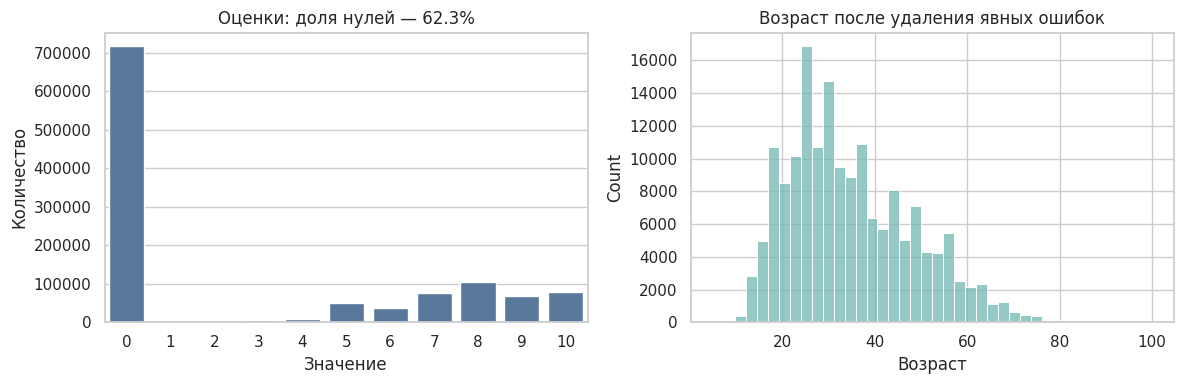

Подозрительных значений года издания: 4,634
Подозрительных значений возраста: 1,248


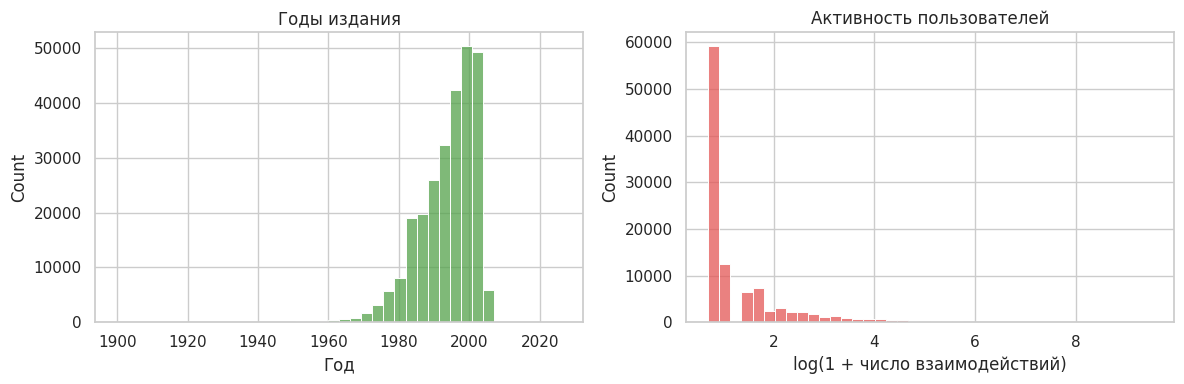

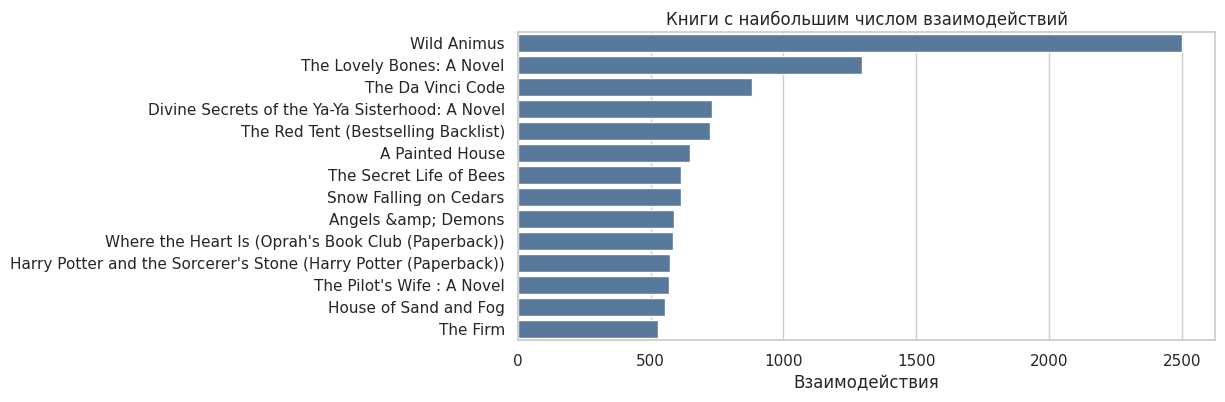

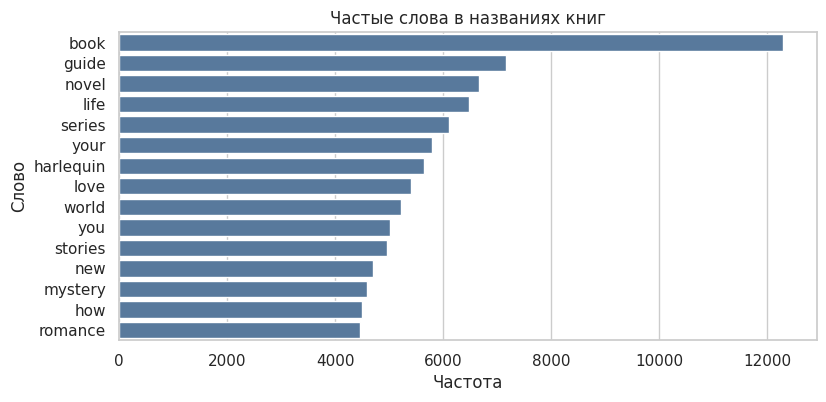

In [21]:
bx_dir = DATA_DIR / "book_crossing"
bx_ratings = pd.read_csv(bx_dir / "BX-Book-Ratings.csv", sep=";", encoding="latin-1", on_bad_lines="skip")
bx_books = pd.read_csv(bx_dir / "BX-Books.csv", sep=";", encoding="latin-1", on_bad_lines="skip")
bx_users = pd.read_csv(bx_dir / "BX-Users.csv", sep=";", encoding="latin-1", on_bad_lines="skip")

add_stats("Book-Crossing", bx_ratings, "User-ID", "ISBN")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=bx_ratings, x="Book-Rating", color="#4c78a8", ax=axes[0])
zero_share = bx_ratings["Book-Rating"].eq(0).mean()
axes[0].set(title=f"Оценки: доля нулей — {zero_share:.1%}", xlabel="Значение", ylabel="Количество")

ages = pd.to_numeric(bx_users["Age"], errors="coerce")
sns.histplot(ages[ages.between(5, 100)], bins=40, ax=axes[1], color="#72b7b2")
axes[1].set(title="Возраст после удаления явных ошибок", xlabel="Возраст")
plt.tight_layout()
plt.show()

years = pd.to_numeric(bx_books["Year-Of-Publication"], errors="coerce")
bad_years = (~years.between(1400, 2026)).sum()
bad_ages = ages.notna().sum() - ages.between(5, 100).sum()
print(f"Подозрительных значений года издания: {bad_years:,}")
print(f"Подозрительных значений возраста: {bad_ages:,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(years[years.between(1900, 2026)], bins=40, ax=axes[0], color="#54a24b")
axes[0].set(title="Годы издания", xlabel="Год")

ratings_per_user = bx_ratings.groupby("User-ID").size()
sns.histplot(np.log1p(ratings_per_user), bins=40, ax=axes[1], color="#e45756")
axes[1].set(title="Активность пользователей", xlabel="log(1 + число взаимодействий)")
plt.tight_layout()
plt.show()

popular_books = bx_ratings["ISBN"].value_counts().head(15).rename("ratings").to_frame()
popular_books = popular_books.join(bx_books.set_index("ISBN")["Book-Title"])
sns.barplot(data=popular_books, x="ratings", y="Book-Title", color="#4c78a8")
plt.title("Книги с наибольшим числом взаимодействий")
plt.xlabel("Взаимодействия")
plt.ylabel("")
plt.show()

plot_words(bx_books["Book-Title"], "Частые слова в названиях книг")


### MIND

MIND — датасет для рекомендаций новостей. В нём есть английские заголовки и краткие тексты новостей, категории, история кликов пользователя и списки показанных новостей.

В столбце `impressions` новости записаны в виде `N123-1 N456-0`: 1 означает клик, 0 — показ без клика. Одна строка соответствует одному показу списка новостей, а не одной новости.


,Датасет,Пользователи,Объекты,Взаимодействия,Разреженность
0,MIND,50000,20288,5843444,99.508%


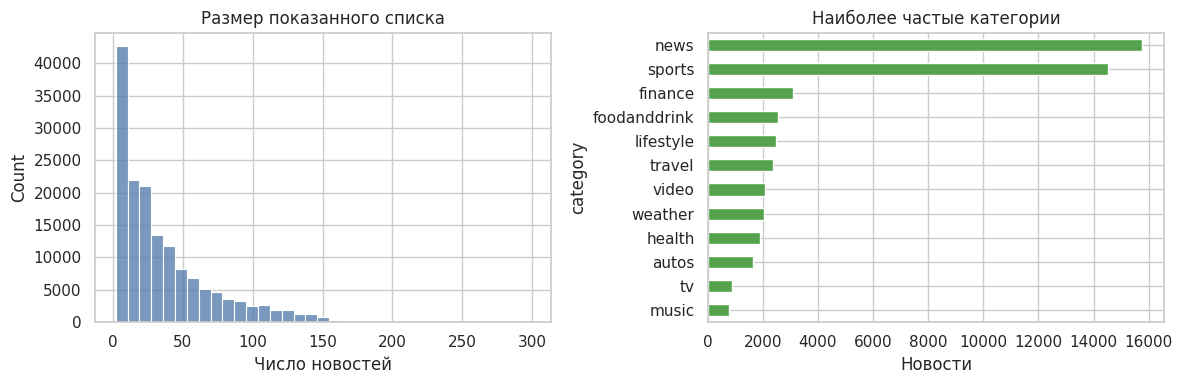

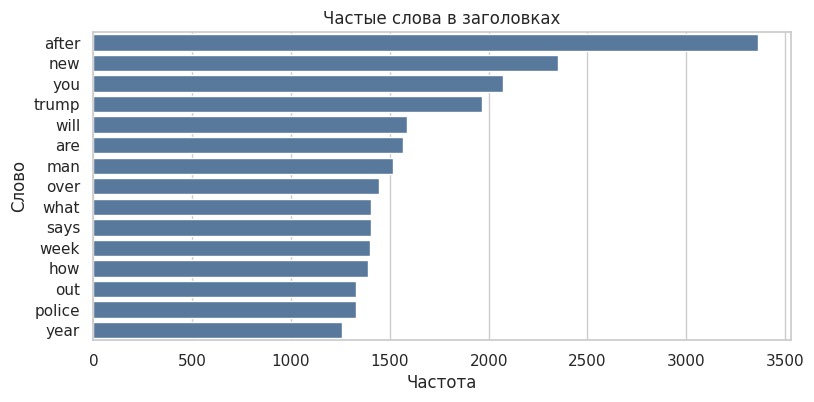

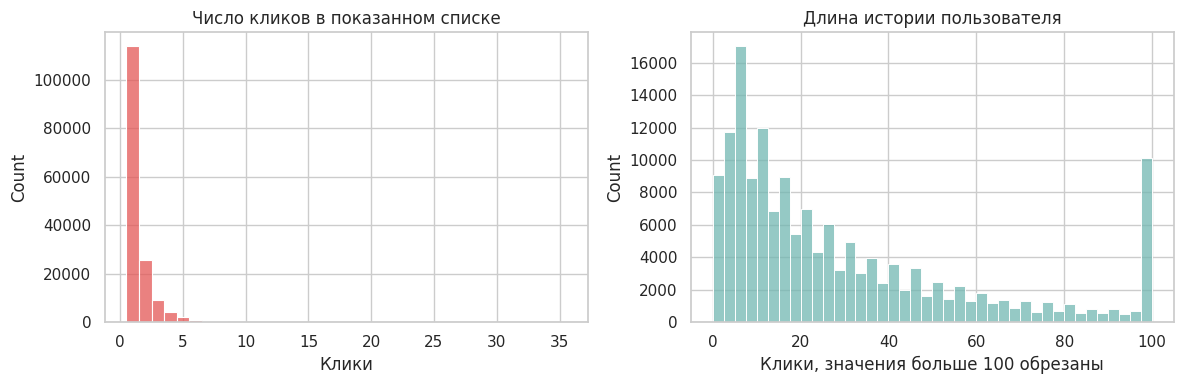

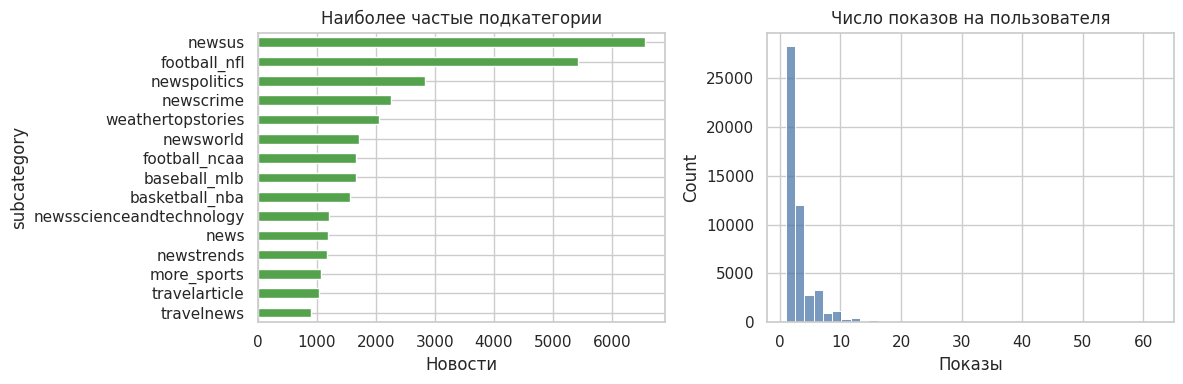

Доля кликов среди показанных новостей: 4.04%
Медианный размер показанного списка: 24
Медианная длина истории: 19


In [22]:
mind_dir = find_file(DATA_DIR / "mind", "behaviors.tsv").parent

behaviors = pd.read_csv(
    mind_dir / "behaviors.tsv",
    sep="\t",
    names=["impression_id", "user_id", "time", "history", "impressions"],
    nrows=MAX_ROWS,
)
news = pd.read_csv(
    mind_dir / "news.tsv",
    sep="\t",
    names=["news_id", "category", "subcategory", "title", "abstract", "url", "title_entities", "abstract_entities"],
)

shown = behaviors[["impression_id", "user_id", "impressions"]].copy()
shown["item"] = shown["impressions"].str.split()
shown = shown.explode("item")
shown[["item_id", "clicked"]] = shown["item"].str.extract(r"^(.+)-([01])$")
shown["clicked"] = shown["clicked"].astype(int)

add_stats("MIND", shown)

slates = shown.groupby("impression_id").agg(
    shown=("item_id", "size"),
    clicked=("clicked", "sum"),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(slates["shown"], bins=35, ax=axes[0], color="#4c78a8")
axes[0].set(title="Размер показанного списка", xlabel="Число новостей")

news["category"].value_counts().head(12).sort_values().plot.barh(
    ax=axes[1], color="#54a24b", title="Наиболее частые категории"
)
axes[1].set_xlabel("Новости")
plt.tight_layout()
plt.show()

plot_words(news["title"], "Частые слова в заголовках")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(slates["clicked"], discrete=True, ax=axes[0], color="#e45756")
axes[0].set(title="Число кликов в показанном списке", xlabel="Клики")

history_length = behaviors["history"].fillna("").str.split().str.len()
sns.histplot(history_length.clip(upper=100), bins=40, ax=axes[1], color="#72b7b2")
axes[1].set(title="Длина истории пользователя", xlabel="Клики, значения больше 100 обрезаны")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
news["subcategory"].value_counts().head(15).sort_values().plot.barh(
    ax=axes[0], color="#54a24b", title="Наиболее частые подкатегории"
)
axes[0].set_xlabel("Новости")

impressions_per_user = behaviors["user_id"].value_counts()
sns.histplot(impressions_per_user, bins=40, ax=axes[1], color="#4c78a8")
axes[1].set(title="Число показов на пользователя", xlabel="Показы")
plt.tight_layout()
plt.show()

print(f"Доля кликов среди показанных новостей: {shown['clicked'].mean():.2%}")
print(f"Медианный размер показанного списка: {slates['shown'].median():.0f}")
print(f"Медианная длина истории: {history_length.median():.0f}")
